In [2]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm
from google.oauth2 import service_account
import numpy as np

df = pd.read_csv("../project/01_data/raw/gdelt_raw.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11901 entries, 0 to 11900
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SQLDATE         11901 non-null  object 
 1   EventCode       11901 non-null  int64  
 2   GoldsteinScale  11901 non-null  float64
 3   NumMentions     11901 non-null  int64  
 4   AvgTone         11901 non-null  float64
 5   ActionGeo_Type  11901 non-null  int64  
 6   ActionGeo_Lat   11901 non-null  float64
 7   ActionGeo_Long  11901 non-null  float64
 8   SOURCEURL       11901 non-null  object 
dtypes: float64(4), int64(3), object(2)
memory usage: 836.9+ KB


In [4]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'])

In [7]:
# ── Type 5 이벤트 전체 확인 ──────────────────────────────────────
df_type5_check = df[df['ActionGeo_Type'] == 5].copy()

print(f"Type 5 이벤트 수: {len(df_type5_check)}건")
print(f"\n[EventCode 분포]")
print(df_type5_check['EventCode'].value_counts().to_string())

print(f"\n[날짜 + EventCode + 좌표 + URL 전체]")
display(df_type5_check[['SQLDATE', 'EventCode', 'GoldsteinScale',
                          'ActionGeo_Lat', 'ActionGeo_Long', 
                          'NumMentions', 'SOURCEURL']]
        .sort_values('SQLDATE')
        .reset_index(drop=True).sort_values('SQLDATE', ascending=False).head(10))

Type 5 이벤트 수: 330건

[EventCode 분포]
EventCode
150    111
190     90
195     29
154     22
194     22
193     19
192     18
151     14
152      3
191      1
202      1

[날짜 + EventCode + 좌표 + URL 전체]


,SQLDATE,EventCode,GoldsteinScale,ActionGeo_Lat,ActionGeo_Long,NumMentions,SOURCEURL
329,2026-04-23,150,-7.2,41.0000,123.000,4,https://www.theepochtimes.com/china/chinese-ai...
328,2026-04-23,150,-7.2,41.0000,123.000,4,https://www.theepochtimes.com/china/chinese-ai...
327,2026-04-07,150,-7.2,23.5711,119.611,10,https://www.taipeitimes.com/News/taiwan/archiv...
326,2026-02-09,190,-10.0,41.0000,123.000,1,https://militarnyi.com/en/news/china-military-...
325,2025-12-31,150,-7.2,23.5711,119.611,10,https://www.globalsecurity.org/wmd/library/new...
324,2025-12-30,150,-7.2,10.0000,76.500,5,https://www.firstpost.com/explainers/firstup-c...
323,2025-12-30,150,-7.2,23.5711,119.611,2,https://www.taipeitimes.com/News/taiwan/archiv...
320,2025-12-29,150,-7.2,26.1642,119.959,4,https://www.taipeitimes.com/News/taiwan/archiv...
319,2025-12-29,150,-7.2,23.5711,119.611,8,https://www.taipeitimes.com/News/taiwan/archiv...
321,2025-12-29,150,-7.2,26.1642,119.959,6,https://www.taipeitimes.com/News/taiwan/archiv...


In [8]:
# ── Type 5 고유 좌표 목록 확인 ───────────────────────────────────
df_type5_check = df[df['ActionGeo_Type'] == 5].copy()

coord_list = df_type5_check.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    event_count  = ('EventCode', 'count'),
    event_codes  = ('EventCode', lambda x: list(x.unique())),
    date_min     = ('SQLDATE', 'min'),
    date_max     = ('SQLDATE', 'max'),
    num_mentions = ('NumMentions', 'sum'),
).reset_index().sort_values('event_count', ascending=False)

print(f"Type 5 고유 좌표 수: {len(coord_list)}개")
print(f"\n[좌표별 이벤트 현황]")
display(coord_list.reset_index(drop=True))

Type 5 고유 좌표 수: 34개

[좌표별 이벤트 현황]


,ActionGeo_Lat,ActionGeo_Long,event_count,event_codes,date_min,date_max,num_mentions
0,41.0000,123.000,104,"[150, 192, 195, 190, 152, 151, 154, 193]",2014-03-23,2026-04-23,745
1,26.5450,117.843,59,"[194, 150, 190, 192, 193, 151, 154, 191, 195]",2014-03-15,2025-12-29,629
2,22.4956,120.614,41,"[150, 194, 193, 190]",2017-05-14,2025-12-18,507
3,36.0000,109.000,25,"[195, 151, 154, 190, 150, 192]",2017-12-12,2025-04-20,214
4,29.0000,120.000,18,"[150, 190]",2016-02-21,2025-04-02,99
5,23.5711,119.611,10,"[150, 193]",2017-03-06,2026-04-07,52
6,24.0000,109.000,7,"[193, 190]",2020-09-04,2020-09-05,75
7,24.4533,118.389,6,"[150, 193, 154, 192]",2020-07-24,2022-09-03,41
8,23.7817,121.393,6,"[190, 150]",2017-05-22,2024-09-05,27
9,26.1642,119.959,5,"[150, 194, 190]",2020-08-13,2025-12-29,20


### 양안 관련 가능성 높은 좌표
- 41.00, 123.00   / Fushun(랴오닝)   / 이벤트 104건, 다양한 코드
- 26.54, 117.84   / Fujian   / 59건, 다양한 코드
- 22.50, 120.61   / 대만 남부   / 41건
- 36.00, 109.00   / Yan'an   / URL 검증 완료
- 23.57, 119.61   / Magong(펑후)   / 10건
- 24.45, 118.39   / Jinhu (금문도)   / 6건

### 명백한 오류 좌표 (제거 후보)
- 31.92, 77.25    / 인도 히마찰프라데시
- 27.25, 80.75    /인도 우타르프라데시
- 32.00, 90.00    / 티베트 고원
- 1.50, 116.50    / 보르네오섬
- 10.00, 76.50    / 인도 케랄라
- 11.00, 78.00    / 인도 타밀나두

In [9]:
# ── 애매한 좌표 URL 확인 ─────────────────────────────────────────
suspect_coords = [
    (35.0252, 138.325),   # 일본 시즈오카
    (31.9167, 77.250),    # 인도
    (32.00,   90.00),     # 티베트
    (22.00,   98.00),     # 미얀마
    (27.25,   80.75),     # 인도
    (1.50,   116.50),     # 보르네오
    (10.00,   76.50),     # 인도 케랄라
    (11.00,   78.00),     # 인도 타밀나두
    (15.33,  120.167),    # 필리핀
    (19.20,  109.60),     # 하이난섬
]

for lat, lon in suspect_coords:
    subset = df[
        (df['ActionGeo_Lat'].round(2) == round(lat, 2)) &
        (df['ActionGeo_Long'].round(2) == round(lon, 2)) &
        (df['ActionGeo_Type'] == 5)
    ]
    print("=" * 60)
    print(f"[{lat}, {lon}] {len(subset)}건")
    print(subset[['SQLDATE', 'EventCode', 'SOURCEURL']].to_string())

[35.0252, 138.325] 2건
       SQLDATE  EventCode                                                                                     SOURCEURL
565 2022-08-05        194                    https://www.rfa.org/english/news/china/taiwan-missiles-08052022135926.html
567 2022-08-05        194  https://www.benarnews.org/english/news/philippine/china-taiwan-live-fire-08052022180105.html
[31.9167, 77.25] 2건
        SQLDATE  EventCode                                         SOURCEURL
8671 2017-12-24        190  http://www.mainstreamweekly.net/article7655.html
8675 2017-12-24        190  http://www.mainstreamweekly.net/article7655.html
[32.0, 90.0] 2건
        SQLDATE  EventCode                                                                                                                             SOURCEURL
6844 2023-08-07        202  https://www.theguardian.com/uk-news/2023/aug/07/chinese-political-slogans-spark-graffiti-free-for-all-on-east-london-wall-brick-lane
8674 2017-12-24        190   

In [10]:
# ── 오류 좌표 제거 ───────────────────────────────────────────────
remove_coords = [
    (31.9167, 77.250),
    (32.00,   90.00),
    (22.00,   98.00),
    (27.25,   80.75),
    (1.50,   116.50),
    (10.00,   76.50),
    (11.00,   78.00),
    (15.33,  120.167),
]

mask = df.apply(
    lambda row: (round(row['ActionGeo_Lat'], 2), 
                 round(row['ActionGeo_Long'], 2)) in 
    [(round(la, 2), round(lo, 2)) for la, lo in remove_coords],
    axis=1
)

df_type5_clean = df[
    (df['ActionGeo_Type'] == 5) & (~mask)
].copy()

print(f"제거 전: {len(df[df['ActionGeo_Type']==5])}건")
print(f"제거 후: {len(df_type5_clean)}건")
print(f"고유 좌표 수: {df_type5_clean.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups}개")

제거 전: 330건
제거 후: 317건
고유 좌표 수: 26개


In [11]:
# ── 검증 날짜 리스트 ─────────────────────────────────────────────
validation_dates = [
    ('2025-12-29', '2025-12-30', 'Strait Thunder 확대'),
    ('2025-04-01', '2025-04-02', 'Strait Thunder-2025A'),
    ('2024-10-14', '2024-10-14', 'Joint Sword-2024B'),
    ('2024-05-23', '2024-05-24', 'Joint Sword-2024A'),
    ('2024-05-20', '2024-05-20', '라이칭더 취임'),
    ('2024-01-13', '2024-01-13', '라이칭더 당선'),
    ('2023-08-12', '2023-08-18', '라이칭더 미국 경유'),
    ('2023-04-05', '2023-04-10', 'Joint Sword + Shandong'),
    ('2022-08-02', '2022-08-10', 'Pelosi 방문 + 포위훈련'),
    ('2021-10-01', '2021-10-04', '역대 최대 ADIZ 진입'),
    ('2021-03-26', '2021-03-26', '미-대만 해경 협력'),
    ('2020-09-17', '2020-09-19', '미국 국무차관 방문'),
    ('2020-08-09', '2020-08-12', '미국 보건장관 방문'),
    ('2019-03-31', '2019-03-31', '중간선 침범'),
    ('2019-01-02', '2019-01-02', '시진핑 무력통일 연설'),
    ('2018-04-18', '2018-04-18', '대만해협 실사격 훈련'),
    ('2016-11-01', '2017-12-31', '폭격기·항모 순환훈련'),
    ('2016-05-20', '2016-05-20', '차이잉원 취임'),
    ('2016-01-16', '2016-01-16', '차이잉원 당선'),
    ('2015-11-07', '2015-11-07', '시진핑-마잉주 회담'),
    ('2015-07-05', '2015-07-05', '주르허 훈련장 공개'),
    ('2014-03-18', '2014-04-10', '해바라기 운동'),
    ('2013-11-23', '2013-11-23', '동중국해 ADIZ 선포'),
]

# ── Type 5 이벤트와 매칭 ─────────────────────────────────────────
df_type5_clean['SQLDATE'] = pd.to_datetime(df_type5_clean['SQLDATE'])

results = []
for start, end, event_name in validation_dates:
    start_dt = pd.to_datetime(start)
    end_dt   = pd.to_datetime(end)
    
    matched = df_type5_clean[
        df_type5_clean['SQLDATE'].between(start_dt, end_dt)
    ]
    
    results.append({
        'event_name'   : event_name,
        'period'       : f"{start} ~ {end}",
        'matched_count': len(matched),
        'unique_coords': matched.groupby(
            ['ActionGeo_Lat','ActionGeo_Long']
        ).ngroups if len(matched) > 0 else 0,
        'event_codes'  : list(matched['EventCode'].unique()) if len(matched) > 0 else [],
        'locations'    : list(matched['ActionGeo_Lat'].astype(str).add(',').add(
                             matched['ActionGeo_Long'].astype(str)
                         ).unique()) if len(matched) > 0 else []
    })

results_df = pd.DataFrame(results)

print("[검증 날짜 매칭 결과]")
display(results_df)

print(f"\n매칭된 검증 이벤트 수: {(results_df['matched_count'] > 0).sum()}/{len(results_df)}")

[검증 날짜 매칭 결과]


,event_name,period,matched_count,unique_coords,event_codes,locations
0,Strait Thunder 확대,2025-12-29 ~ 2025-12-30,5,3,[150],"[26.545,117.843, 26.1642,119.959, 23.5711,119...."
1,Strait Thunder-2025A,2025-04-01 ~ 2025-04-02,1,1,[150],"[29.0,120.0]"
2,Joint Sword-2024B,2024-10-14 ~ 2024-10-14,3,1,[150],"[41.0,123.0]"
3,Joint Sword-2024A,2024-05-23 ~ 2024-05-24,0,0,[],[]
4,라이칭더 취임,2024-05-20 ~ 2024-05-20,0,0,[],[]
5,라이칭더 당선,2024-01-13 ~ 2024-01-13,0,0,[],[]
6,라이칭더 미국 경유,2023-08-12 ~ 2023-08-18,0,0,[],[]
7,Joint Sword + Shandong,2023-04-05 ~ 2023-04-10,12,2,"[190, 150, 194, 151, 191]","[26.545,117.843, 38.0,102.0]"
8,Pelosi 방문 + 포위훈련,2022-08-02 ~ 2022-08-10,27,8,"[150, 192, 194, 195, 154, 190]","[41.0,123.0, 22.4956,120.614, 26.545,117.843, ..."
9,역대 최대 ADIZ 진입,2021-10-01 ~ 2021-10-04,0,0,[],[]



매칭된 검증 이벤트 수: 9/23


In [12]:
import pandas as pd
import numpy as np

# ── 검증 날짜 리스트 ─────────────────────────────────────────────
validation_events = [
    ('2025-12-29', '2025-12-30', 'Strait Thunder 확대',        '매우높음'),
    ('2025-04-01', '2025-04-02', 'Strait Thunder-2025A',       '매우높음'),
    ('2024-10-14', '2024-10-14', 'Joint Sword-2024B',          '매우높음'),
    ('2024-05-23', '2024-05-24', 'Joint Sword-2024A',          '매우높음'),
    ('2024-05-20', '2024-05-20', '라이칭더 취임',               '중간~높음'),
    ('2024-01-13', '2024-01-13', '라이칭더 당선',               '높음'),
    ('2023-08-12', '2023-08-18', '라이칭더 미국 경유',          '높음'),
    ('2023-04-05', '2023-04-10', 'Joint Sword + Shandong',     '매우높음'),
    ('2022-08-02', '2022-08-10', 'Pelosi 방문 + 포위훈련',      '매우높음'),
    ('2021-10-01', '2021-10-04', '역대 최대 ADIZ 진입',         '매우높음'),
    ('2021-03-26', '2021-03-26', '미-대만 해경 협력',           '중간~높음'),
    ('2020-09-17', '2020-09-19', '미국 국무차관 방문',          '높음'),
    ('2020-08-09', '2020-08-12', '미국 보건장관 방문',          '높음'),
    ('2019-03-31', '2019-03-31', '중간선 침범',                 '매우높음'),
    ('2019-01-02', '2019-01-02', '시진핑 무력통일 연설',        '높음'),
    ('2018-04-18', '2018-04-18', '대만해협 실사격 훈련',        '높음'),
    ('2016-11-01', '2017-12-31', '폭격기·항모 순환훈련',        '매우높음'),
    ('2016-05-20', '2016-05-20', '차이잉원 취임',               '높음'),
    ('2016-01-16', '2016-01-16', '차이잉원 당선',               '중간~높음'),
    ('2015-11-07', '2015-11-07', '시진핑-마잉주 회담',          '중간'),
    ('2015-07-05', '2015-07-05', '주르허 훈련장 공개',          '매우높음'),
    ('2014-03-18', '2014-04-10', '해바라기 운동',               '중간'),
    ('2013-11-23', '2013-11-23', '동중국해 ADIZ 선포',          '매우높음'),
]

val_df = pd.DataFrame(validation_events,
                      columns=['date_start', 'date_end', 
                                'event_name', 'importance'])
val_df['date_start'] = pd.to_datetime(val_df['date_start'])
val_df['date_end']   = pd.to_datetime(val_df['date_end'])

# 중요도 수치 변환
importance_map = {'매우높음': 1.0, '높음': 0.75, '중간~높음': 0.5, '중간': 0.25}
val_df['importance_score'] = val_df['importance'].map(importance_map)

print(f"검증 이벤트 수: {len(val_df)}개")

# ── Step 2. df와 날짜 매칭 ───────────────────────────────────────
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'])

# 각 이벤트 행에 검증 이벤트 매칭 여부 및 중요도 부여
def match_validation(row):
    for _, v in val_df.iterrows():
        if v['date_start'] <= row['SQLDATE'] <= v['date_end']:
            return pd.Series({
                'is_validation'   : True,
                'val_event_name'  : v['event_name'],
                'val_importance'  : v['importance_score']
            })
    return pd.Series({
        'is_validation' : False,
        'val_event_name': None,
        'val_importance': 0.0
    })

df[['is_validation', 'val_event_name', 'val_importance']] = \
    df.apply(match_validation, axis=1)

print(f"\n전체 이벤트 수       : {len(df):,}")
print(f"검증 날짜 매칭 이벤트: {df['is_validation'].sum():,}")
print(f"미매칭 이벤트        : {(~df['is_validation']).sum():,}")
print(f"\n[검증 이벤트별 매칭 수]")
print(df[df['is_validation']]['val_event_name']
      .value_counts().to_string())

검증 이벤트 수: 23개

전체 이벤트 수       : 11,901
검증 날짜 매칭 이벤트: 2,149
미매칭 이벤트        : 9,752

[검증 이벤트별 매칭 수]
val_event_name
Pelosi 방문 + 포위훈련          669
폭격기·항모 순환훈련               553
Joint Sword + Shandong    334
역대 최대 ADIZ 진입             102
Strait Thunder 확대          98
Joint Sword-2024A          82
Strait Thunder-2025A       78
미국 국무차관 방문                 65
Joint Sword-2024B          39
해바라기 운동                    31
미국 보건장관 방문                 20
대만해협 실사격 훈련                16
라이칭더 미국 경유                 15
시진핑-마잉주 회담                 12
라이칭더 당선                    11
차이잉원 취임                     7
중간선 침범                      5
차이잉원 당선                     5
미-대만 해경 협력                  4
라이칭더 취임                     2
시진핑 무력통일 연설                 1


In [13]:
# ── 좌표별 집계 ──────────────────────────────────────────────────
coord_agg = df.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    total_events        = ('EventCode', 'count'),
    val_events          = ('is_validation', 'sum'),        # 검증 날짜 매칭 이벤트 수
    total_mentions      = ('NumMentions', 'sum'),
    goldstein_weight    = ('GoldsteinScale', lambda x: abs(x).sum()),
    importance_sum      = ('val_importance', 'sum'),       # 중요도 가중치 합계
    avg_importance      = ('val_importance', 'mean'),      # 평균 중요도
).reset_index()

# 검증 이벤트 비율
coord_agg['val_ratio'] = coord_agg['val_events'] / coord_agg['total_events']

print(f"고유 좌표 수: {len(coord_agg):,}")
print(f"\n[기술통계]")
display(coord_agg.describe())

고유 좌표 수: 590

[기술통계]


,ActionGeo_Lat,ActionGeo_Long,total_events,val_events,total_mentions,goldstein_weight,importance_sum,avg_importance,val_ratio
count,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000
mean,27.820008,92.229461,20.171186,3.642373,268.242373,177.863220,3.521186,0.167400,0.173321
std,13.181031,61.056428,201.351038,35.433420,3245.035955,1771.337547,34.386093,0.322789,0.328870
min,-41.300000,-157.972000,1.000000,0.000000,1.000000,7.200000,0.000000,0.000000,0.000000
25%,23.214000,105.000000,1.000000,0.000000,5.000000,10.000000,0.000000,0.000000,0.000000
50%,26.161550,116.585500,2.000000,0.000000,10.000000,19.000000,0.000000,0.000000,0.000000
75%,34.305400,120.775750,4.000000,1.000000,30.000000,39.750000,1.000000,0.166667,0.177988
max,67.939700,178.417000,3899.000000,684.000000,69646.000000,34310.900000,665.000000,1.000000,1.000000


In [14]:
# ── 관심 구역 필터링 ─────────────────────────────────────────────
LAT_RANGE = (15, 45)
LON_RANGE = (100, 145)

df_filtered = df[
    df['ActionGeo_Lat'].between(*LAT_RANGE) &
    df['ActionGeo_Long'].between(*LON_RANGE)
].copy()

print(f"필터링 전: {len(df):,}건, {df.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups}개 좌표")
print(f"필터링 후: {len(df_filtered):,}건, {df_filtered.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups}개 좌표")

# ── 좌표별 재집계 ────────────────────────────────────────────────
coord_agg = df_filtered.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    total_events     = ('EventCode', 'count'),
    val_events       = ('is_validation', 'sum'),
    total_mentions   = ('NumMentions', 'sum'),
    goldstein_weight = ('GoldsteinScale', lambda x: abs(x).sum()),
    importance_sum   = ('val_importance', 'sum'),
    avg_importance   = ('val_importance', 'mean'),
).reset_index()

coord_agg['val_ratio'] = coord_agg['val_events'] / coord_agg['total_events']

print(f"\n[필터링 후 기술통계]")
display(coord_agg[['total_events','val_events','total_mentions',
                    'importance_sum','val_ratio']].describe())

필터링 전: 11,901건, 590개 좌표
필터링 후: 11,134건, 435개 좌표

[필터링 후 기술통계]


,total_events,val_events,total_mentions,importance_sum,val_ratio
count,435.000000,435.000000,435.000000,435.000000,435.000000
mean,25.595402,4.593103,345.303448,4.433333,0.165633
std,233.754020,41.089623,3774.529552,39.872289,0.316475
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,10.000000,0.000000,0.000000
75%,5.000000,1.000000,36.500000,1.000000,0.177405
max,3899.000000,684.000000,69646.000000,665.000000,1.000000


In [15]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler

# ── 1. 정규화 ────────────────────────────────────────────────────
# RobustScaler: 이상치에 강건한 정규화
robust = RobustScaler()
minmax = MinMaxScaler()

score_cols = {
    'total_events'    : 'score_freq',
    'total_mentions'  : 'score_mentions',
    'goldstein_weight': 'score_goldstein',
    'importance_sum'  : 'score_importance',
    'val_ratio'       : 'score_val_ratio',
}

for raw, scaled in score_cols.items():
    coord_agg[scaled] = minmax.fit_transform(
        robust.fit_transform(coord_agg[[raw]])
    )

# ── 2. 가중합 ────────────────────────────────────────────────────
# importance_sum: 검증된 실제 위험 이벤트 반영 → 가장 높은 가중치
# val_ratio: 전체 이벤트 중 위험 이벤트 비율
# total_mentions: 언론 주목도
# score_freq: 이벤트 빈도
# goldstein: 위험도

weights = {
    'score_importance': 0.35,
    'score_val_ratio' : 0.25,
    'score_mentions'  : 0.20,
    'score_freq'      : 0.10,
    'score_goldstein' : 0.10,
}

coord_agg['priority_score'] = sum(
    coord_agg[col] * w for col, w in weights.items()
)

# ── 3. 결과 확인 ─────────────────────────────────────────────────
top20 = coord_agg.nlargest(20, 'priority_score')[
    ['ActionGeo_Lat', 'ActionGeo_Long', 'priority_score',
     'score_importance', 'score_val_ratio',
     'score_mentions', 'total_events', 'val_events',
     'importance_sum']
].reset_index(drop=True)

print("[Priority Score Top 20]")
display(top20)

[Priority Score Top 20]


,ActionGeo_Lat,ActionGeo_Long,priority_score,score_importance,score_val_ratio,score_mentions,total_events,val_events,importance_sum
0,39.9289,116.388,0.793857,1.000000,0.175430,1.000000,3899,684,665.00
1,25.0478,121.532,0.536037,0.713910,0.176238,0.495283,2786,491,474.75
2,28.7925,117.262,0.253705,0.004511,1.000000,0.010123,3,3,3.00
3,24.9167,117.867,0.253546,0.009023,1.000000,0.000531,6,6,6.00
4,22.1906,120.689,0.253501,0.009023,1.000000,0.000345,6,6,6.00
5,36.2545,140.380,0.251689,0.004511,1.000000,0.000086,3,3,3.00
6,28.5500,115.933,0.251141,0.003008,1.000000,0.000129,2,2,2.00
7,24.0253,121.136,0.251136,0.003008,1.000000,0.000101,2,2,2.00
8,23.4700,120.957,0.251133,0.003008,1.000000,0.000086,2,2,2.00
9,22.9044,112.885,0.251130,0.003008,1.000000,0.000072,2,2,2.00


al_ratio = 1.0 (전체 이벤트가 모두 검증 날짜에 해당)인 좌표들이 상위를 차지하고 있는데 이 좌표들은 total_events가 2~6건에 불과함. 2건 중 2건이 검증 날짜에 해당하면 val_ratio = 1.0이 되어 높은 점수를 받지만, 실제로는 의미없는 좌표라는 문제.

최소 기준을 정해보자!

In [16]:
# ── 최소 이벤트 수 필터링 (신뢰도 확보) ─────────────────────────
MIN_EVENTS = 10  # 최소 10건 이상인 좌표만 대상

coord_agg_filtered = coord_agg[
    coord_agg['total_events'] >= MIN_EVENTS
].copy()

print(f"전체 좌표 수       : {len(coord_agg):,}")
print(f"필터링 후 좌표 수  : {len(coord_agg_filtered):,}")

# ── 재정규화 ─────────────────────────────────────────────────────
robust = RobustScaler()
minmax = MinMaxScaler()

score_cols = {
    'total_events'    : 'score_freq',
    'total_mentions'  : 'score_mentions',
    'goldstein_weight': 'score_goldstein',
    'importance_sum'  : 'score_importance',
    'val_events'      : 'score_val_events',  # val_ratio 대신 절대값 사용
}

for raw, scaled in score_cols.items():
    coord_agg_filtered[scaled] = minmax.fit_transform(
        robust.fit_transform(coord_agg_filtered[[raw]])
    )

# ── 가중합 ───────────────────────────────────────────────────────
weights = {
    'score_importance' : 0.40,
    'score_val_events' : 0.25,
    'score_mentions'   : 0.20,
    'score_freq'       : 0.10,
    'score_goldstein'  : 0.05,
}

coord_agg_filtered['priority_score'] = sum(
    coord_agg_filtered[col] * w for col, w in weights.items()
)

# ── 결과 확인 ────────────────────────────────────────────────────
print("\n[Priority Score Top 20]")
display(coord_agg_filtered.nlargest(20, 'priority_score')[
    ['ActionGeo_Lat', 'ActionGeo_Long', 'priority_score',
     'score_importance', 'score_val_events',
     'score_mentions', 'total_events', 'val_events',
     'importance_sum']
].reset_index(drop=True))

전체 좌표 수       : 435
필터링 후 좌표 수  : 61

[Priority Score Top 20]


,ActionGeo_Lat,ActionGeo_Long,priority_score,score_importance,score_val_events,score_mentions,total_events,val_events,importance_sum
0,39.9289,116.388,1.000000,1.000000,1.000000,1.000000,3899,684,665.00
1,25.0478,121.532,0.671192,0.713910,0.717836,0.495066,2786,491,474.75
2,24.0000,119.000,0.185348,0.188722,0.191520,0.174201,722,131,125.50
3,24.0000,121.000,0.096780,0.114662,0.112573,0.041040,387,77,76.25
4,24.4367,118.318,0.073707,0.075564,0.074561,0.059312,340,51,50.25
5,24.1098,113.005,0.054138,0.047368,0.046784,0.047648,381,32,31.50
6,21.4167,121.500,0.033566,0.042857,0.042398,0.012296,99,29,28.50
7,41.0000,123.000,0.031551,0.039098,0.040936,0.010256,104,28,26.00
8,20.6827,109.951,0.029773,0.042105,0.040936,0.004209,58,28,28.00
9,25.0327,121.275,0.027264,0.033083,0.033626,0.011765,95,23,22.00


- 1순위 39.93, 116.39	 Beijing
- 2순위 25.05, 121.53  Taipei
- 3순위 24.00, 119.00  대만해협 중심 - 핵심 해상 구역
- 4순위 24.00, 121.00  대만 중부 - Puli 인근
- 5순위 24.44, 118.32  금문도 - 최전선
- 7순위 41.00, 123.00  Fushun - 랴오닝 군사기지
- 8순위 20.68, 109.95  하이난 - 남해함대 기지
- 14순위 26.55, 117.84  대만해협 맞은편

Taipei는 Beijing과 달리 실제 군사 타격 대상이 될 수 있는 도시로 대만 총통부, 국방부, 군사령부가 모두 Taipei에 있다!
우선 Beijing 제거하고 좌표를 정리해보자.

In [17]:
# ── Beijing 제거 ─────────────────────────────────────────────────
coord_agg_final = coord_agg_filtered[
    ~((coord_agg_filtered['ActionGeo_Lat'].round(2) == 39.93) &
      (coord_agg_filtered['ActionGeo_Long'].round(2) == 116.39))
].copy()

# ── 재정규화 및 Priority Score 재산출 ───────────────────────────
for raw, scaled in score_cols.items():
    coord_agg_final[scaled] = minmax.fit_transform(
        robust.fit_transform(coord_agg_final[[raw]])
    )

coord_agg_final['priority_score'] = sum(
    coord_agg_final[col] * w for col, w in weights.items()
)

print(f"최종 좌표 수: {len(coord_agg_final):,}")
print("\n[Priority Score Top 20]")
display(coord_agg_final.nlargest(20, 'priority_score')[
    ['ActionGeo_Lat', 'ActionGeo_Long', 'priority_score',
     'score_importance', 'score_val_events',
     'score_mentions', 'total_events', 'val_events',
     'importance_sum']
].reset_index(drop=True))

최종 좌표 수: 60

[Priority Score Top 20]


,ActionGeo_Lat,ActionGeo_Long,priority_score,score_importance,score_val_events,score_mentions,total_events,val_events,importance_sum
0,25.0478,121.532,1.000000,1.000000,1.000000,1.000000,2786,491,474.75
1,24.0000,119.000,0.280806,0.264350,0.266802,0.351874,722,131,125.50
2,24.0000,121.000,0.140417,0.160611,0.156823,0.082898,387,77,76.25
3,24.4367,118.318,0.110434,0.105845,0.103870,0.119806,340,51,50.25
4,24.1098,113.005,0.081632,0.066351,0.065173,0.096245,381,32,31.50
5,21.4167,121.500,0.048455,0.060032,0.059063,0.024838,99,29,28.50
6,41.0000,123.000,0.045383,0.054766,0.057026,0.020717,104,28,26.00
7,20.6827,109.951,0.042145,0.058978,0.057026,0.008502,58,28,28.00
8,25.0327,121.275,0.039579,0.046340,0.046843,0.023764,95,23,22.00
9,25.0177,121.174,0.035784,0.046340,0.044807,0.014421,68,22,22.00


In [18]:
# ── 역지오코딩 ───────────────────────────────────────────────────
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm.auto import tqdm

geolocator = Nominatim(user_agent="gdelt_taiwan_final")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_place(row):
    try:
        loc = reverse(f"{row['ActionGeo_Lat']}, {row['ActionGeo_Long']}", 
                      language='en', zoom=10)
        if loc:
            addr = loc.raw.get('address', {})
            return pd.Series({
                'country' : addr.get('country', ''),
                'city'    : addr.get('city', addr.get('town', 
                            addr.get('county', ''))),
            })
    except:
        pass
    return pd.Series({'country': None, 'city': None})

tqdm.pandas()
coord_agg_final[['country', 'city']] = \
    coord_agg_final.progress_apply(get_place, axis=1)

# ── 최종 결과 출력 ───────────────────────────────────────────────
print("[최종 Priority Score Top 20 with 지명]")
display(coord_agg_final.nlargest(20, 'priority_score')[
    ['country', 'city', 'ActionGeo_Lat', 'ActionGeo_Long',
     'priority_score', 'total_events', 'val_events', 'importance_sum']
].reset_index(drop=True))

  0%|          | 0/60 [00:00<?, ?it/s]

[최종 Priority Score Top 20 with 지명]


,country,city,ActionGeo_Lat,ActionGeo_Long,priority_score,total_events,val_events,importance_sum
0,Taiwan,Taipei,25.0478,121.532,1.000000,2786,491,474.75
1,None,None,24.0000,119.000,0.280806,722,131,125.50
2,Taiwan,Puli Township,24.0000,121.000,0.140417,387,77,76.25
3,Taiwan,Jincheng Township,24.4367,118.318,0.110434,340,51,50.25
4,China,Yingde City,24.1098,113.005,0.081632,381,32,31.50
5,None,None,21.4167,121.500,0.048455,99,29,28.50
6,China,Dong'anshan Subdistrict,41.0000,123.000,0.045383,104,28,26.00
7,China,Zhanjiang City,20.6827,109.951,0.042145,58,28,28.00
8,Taiwan,Taoyuan City,25.0327,121.275,0.039579,95,23,22.00
9,Taiwan,Taoyuan City,25.0177,121.174,0.035784,68,22,22.00


In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm.auto import tqdm

# ================================================================
# STEP 1. 기본 전처리
# ================================================================
df_pipe = df.copy()

# 날짜 변환
df_pipe['SQLDATE'] = pd.to_datetime(df_pipe['SQLDATE'])

# 좌표 정규화 (소수점 2자리)
df_pipe['ActionGeo_Lat'] = df_pipe['ActionGeo_Lat'].round(2)
df_pipe['ActionGeo_Long'] = df_pipe['ActionGeo_Long'].round(2)

print(f"[STEP 1] 기본 전처리 완료: {len(df_pipe):,}건")

# ================================================================
# STEP 2. 관심 구역 필터링 (위도 15~45°N, 경도 100~145°E)
# ================================================================
df_pipe = df_pipe[
    df_pipe['ActionGeo_Lat'].between(15, 45) &
    df_pipe['ActionGeo_Long'].between(100, 145)
].copy()

print(f"[STEP 2] 관심 구역 필터링: {len(df_pipe):,}건, "
      f"{df_pipe.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups}개 좌표")

# ================================================================
# STEP 3. 명백한 오류 좌표 제거
# ================================================================
error_coords = [
    (20.00, 135.00),  # 서태평양
    (41.33, 140.33),  # 일본 혼슈 북부
    (31.92,  77.25),  # 인도
    (32.00,  90.00),  # 티베트
    (22.00,  98.00),  # 미얀마
    (27.25,  80.75),  # 인도
    (1.50,  116.50),  # 보르네오
    (10.00,  76.50),  # 인도 케랄라
    (11.00,  78.00),  # 인도 타밀나두
    (15.33, 120.17),  # 필리핀
]

mask_error = df_pipe.apply(
    lambda row: (row['ActionGeo_Lat'], 
                 row['ActionGeo_Long']) in error_coords, axis=1
)
df_pipe = df_pipe[~mask_error].copy()

print(f"[STEP 3] 오류 좌표 제거: {len(df_pipe):,}건, "
      f"{df_pipe.groupby(['ActionGeo_Lat','ActionGeo_Long']).ngroups}개 좌표")

# ================================================================
# STEP 4. 검증 날짜 매칭
# ================================================================
validation_events = [
    ('2025-12-29', '2025-12-30', 'Strait Thunder 확대',        1.00),
    ('2025-04-01', '2025-04-02', 'Strait Thunder-2025A',       1.00),
    ('2024-10-14', '2024-10-14', 'Joint Sword-2024B',          1.00),
    ('2024-05-23', '2024-05-24', 'Joint Sword-2024A',          1.00),
    ('2024-05-20', '2024-05-20', '라이칭더 취임',               0.50),
    ('2024-01-13', '2024-01-13', '라이칭더 당선',               0.75),
    ('2023-08-12', '2023-08-18', '라이칭더 미국 경유',          0.75),
    ('2023-04-05', '2023-04-10', 'Joint Sword + Shandong',     1.00),
    ('2022-08-02', '2022-08-10', 'Pelosi 방문 + 포위훈련',      1.00),
    ('2021-10-01', '2021-10-04', '역대 최대 ADIZ 진입',         1.00),
    ('2021-03-26', '2021-03-26', '미-대만 해경 협력',           0.50),
    ('2020-09-17', '2020-09-19', '미국 국무차관 방문',          0.75),
    ('2020-08-09', '2020-08-12', '미국 보건장관 방문',          0.75),
    ('2019-03-31', '2019-03-31', '중간선 침범',                 1.00),
    ('2019-01-02', '2019-01-02', '시진핑 무력통일 연설',        0.75),
    ('2018-04-18', '2018-04-18', '대만해협 실사격 훈련',        0.75),
    ('2016-11-01', '2017-12-31', '폭격기·항모 순환훈련',        1.00),
    ('2016-05-20', '2016-05-20', '차이잉원 취임',               0.75),
    ('2016-01-16', '2016-01-16', '차이잉원 당선',               0.50),
    ('2015-11-07', '2015-11-07', '시진핑-마잉주 회담',          0.25),
    ('2015-07-05', '2015-07-05', '주르허 훈련장 공개',          1.00),
    ('2014-03-18', '2014-04-10', '해바라기 운동',               0.25),
    ('2013-11-23', '2013-11-23', '동중국해 ADIZ 선포',          1.00),
]

val_df = pd.DataFrame(validation_events,
                      columns=['date_start', 'date_end',
                                'event_name', 'importance_score'])
val_df['date_start'] = pd.to_datetime(val_df['date_start'])
val_df['date_end']   = pd.to_datetime(val_df['date_end'])

def match_validation(row):
    for _, v in val_df.iterrows():
        if v['date_start'] <= row['SQLDATE'] <= v['date_end']:
            return pd.Series({
                'is_validation' : True,
                'val_importance': v['importance_score']
            })
    return pd.Series({'is_validation': False, 'val_importance': 0.0})

df_pipe[['is_validation', 'val_importance']] = \
    df_pipe.apply(match_validation, axis=1)

print(f"[STEP 4] 검증 날짜 매칭: {df_pipe['is_validation'].sum():,}건 매칭")

# ================================================================
# STEP 5. 좌표별 집계
# ================================================================
coord_agg = df_pipe.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg(
    total_events     = ('EventCode', 'count'),
    val_events       = ('is_validation', 'sum'),
    total_mentions   = ('NumMentions', 'sum'),
    goldstein_weight = ('GoldsteinScale', lambda x: abs(x).sum()),
    importance_sum   = ('val_importance', 'sum'),
).reset_index()

# 최소 이벤트 수 필터 (신뢰도 확보)
coord_agg = coord_agg[coord_agg['total_events'] >= 10].copy()

print(f"[STEP 5] 집계 완료: {len(coord_agg):,}개 좌표 (최소 10건 이상)")

# ================================================================
# STEP 6. 역지오코딩
# ================================================================
geolocator = Nominatim(user_agent="gdelt_taiwan_pipeline")
reverse    = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_place(row):
    try:
        loc = reverse(f"{row['ActionGeo_Lat']}, {row['ActionGeo_Long']}",
                      language='en', zoom=10)
        if loc:
            addr = loc.raw.get('address', {})
            return pd.Series({
                'country': addr.get('country', ''),
                'city'   : addr.get('city', addr.get(
                           'town', addr.get('county', '')))
            })
    except:
        pass
    return pd.Series({'country': None, 'city': None})

tqdm.pandas()
coord_agg[['country', 'city']] = coord_agg.progress_apply(get_place, axis=1)

print(f"[STEP 6] 역지오코딩 완료")
print(coord_agg['country'].value_counts(dropna=False))

# ================================================================
# STEP 7. 관심 국가 필터링 + 이상치 제거
# ================================================================
# 관심 국가: China, Taiwan, 해상(None)
coord_agg = coord_agg[
    coord_agg['country'].isin(['China', 'Taiwan']) |
    coord_agg['country'].isna()
].copy()

# 이전에 확인된 이상치 도시 제거
remove_cities = ['Yingde City', 'Puli Township']
coord_agg = coord_agg[
    ~coord_agg['city'].isin(remove_cities)
].copy()

# Beijing 제거
coord_agg = coord_agg[
    ~((coord_agg['ActionGeo_Lat'] == 39.93) &
      (coord_agg['ActionGeo_Long'] == 116.39))
].copy()

print(f"[STEP 7] 최종 좌표 수: {len(coord_agg):,}개")

# ================================================================
# STEP 8. Priority Score 산출
# ================================================================
robust = RobustScaler()
minmax = MinMaxScaler()

score_cols = {
    'total_events'    : 'score_freq',
    'total_mentions'  : 'score_mentions',
    'goldstein_weight': 'score_goldstein',
    'importance_sum'  : 'score_importance',
    'val_events'      : 'score_val_events',
}

for raw, scaled in score_cols.items():
    coord_agg[scaled] = minmax.fit_transform(
        robust.fit_transform(coord_agg[[raw]])
    )

weights = {
    'score_importance' : 0.40,
    'score_val_events' : 0.25,
    'score_mentions'   : 0.20,
    'score_freq'       : 0.10,
    'score_goldstein'  : 0.05,
}

coord_agg['priority_score'] = sum(
    coord_agg[col] * w for col, w in weights.items()
)

# ================================================================
# STEP 9. 최종 결과 출력
# ================================================================
print("\n[최종 Priority Score Top 20]")
display(coord_agg.nlargest(20, 'priority_score')[
    ['country', 'city', 'ActionGeo_Lat', 'ActionGeo_Long',
     'priority_score', 'total_events', 'val_events', 'importance_sum']
].reset_index(drop=True))

[STEP 1] 기본 전처리 완료: 11,901건
[STEP 2] 관심 구역 필터링: 11,134건, 432개 좌표
[STEP 3] 오류 좌표 제거: 11,125건, 429개 좌표
[STEP 4] 검증 날짜 매칭: 1,998건 매칭
[STEP 5] 집계 완료: 61개 좌표 (최소 10건 이상)


  0%|          | 0/61 [00:00<?, ?it/s]

[STEP 6] 역지오코딩 완료
country
China          35
Taiwan         16
None            4
Japan           3
Philippines     1
South Korea     1
North Korea     1
Name: count, dtype: int64
[STEP 7] 최종 좌표 수: 52개

[최종 Priority Score Top 20]


,country,city,ActionGeo_Lat,ActionGeo_Long,priority_score,total_events,val_events,importance_sum
0,Taiwan,Taipei,25.05,121.53,1.000000,2786,491,474.75
1,None,None,24.00,119.00,0.280806,722,131,125.50
2,Taiwan,Jincheng Township,24.44,118.32,0.110434,340,51,50.25
3,None,None,21.42,121.50,0.048455,99,29,28.50
4,China,Dong'anshan Subdistrict,41.00,123.00,0.045383,104,28,26.00
5,China,Zhanjiang City,20.68,109.95,0.042145,58,28,28.00
6,Taiwan,Taoyuan City,25.03,121.28,0.039579,95,23,22.00
7,Taiwan,Taoyuan City,25.02,121.17,0.035784,68,22,22.00
8,China,Shanghai,31.22,121.46,0.032902,145,16,11.50
9,China,Xuyi County,32.98,118.85,0.029803,52,19,19.00


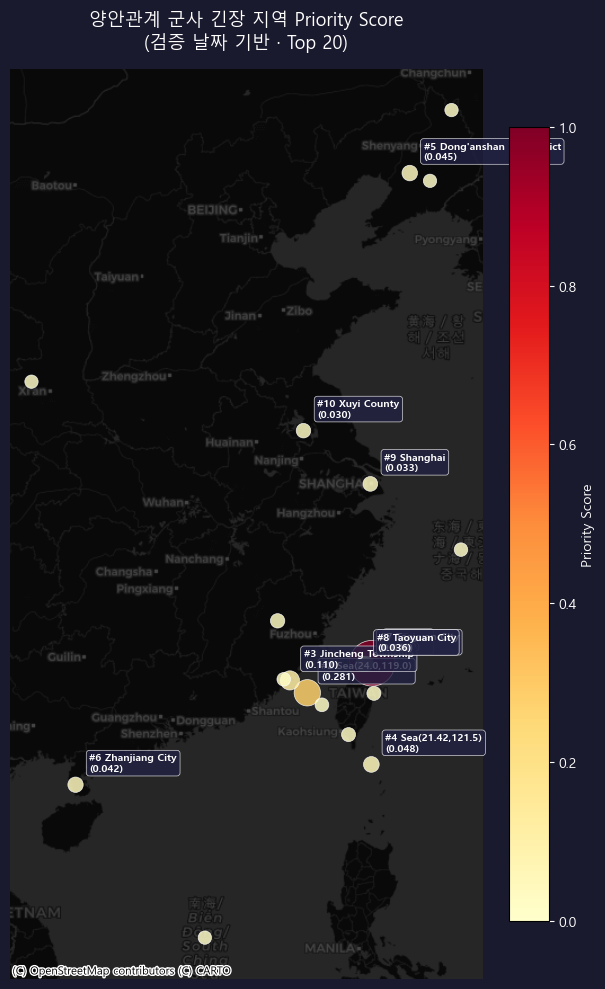

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# 한글 폰트 및 설정 (Windows 환경)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# ── GeoDataFrame 변환 ────────────────────────────────────────────
top20 = coord_agg.nlargest(20, 'priority_score').copy()

gdf = gpd.GeoDataFrame(
    top20,
    geometry=[Point(xy) for xy in zip(
        top20['ActionGeo_Long'],
        top20['ActionGeo_Lat']
    )],
    crs='EPSG:4326'
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 10))

# ── 컬러 설정 ────────────────────────────────────────────────────
norm  = Normalize(vmin=0, vmax=1)
cmap  = plt.cm.YlOrRd

colors = [cmap(norm(s)) for s in gdf['priority_score']]
sizes  = 80 + gdf['priority_score'] * 1000

# ── 좌표 플롯 ────────────────────────────────────────────────────
gdf.plot(
    ax=ax, color=colors, markersize=sizes,
    alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3
)

# ── 상위 10개 라벨 ───────────────────────────────────────────────
top10 = gdf.sort_values('priority_score', ascending=False).head(10)
for i, row in enumerate(top10.itertuples()):
    label = row.city if row.city else f"Sea({row.ActionGeo_Lat},{row.ActionGeo_Long})"
    ax.annotate(
        f"#{i+1} {label}\n({row.priority_score:.3f})",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(10, 10), textcoords='offset points',
        color='white', fontsize=7.5, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#222244', alpha=0.8,
                  edgecolor='white', linewidth=0.5)
    )

# ── 지도 배경 ────────────────────────────────────────────────────
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.DarkMatter,
    zoom=5
)

# ── 컬러바 ───────────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Priority Score', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# ── 스타일 ───────────────────────────────────────────────────────
ax.set_axis_off()
fig.patch.set_facecolor('#1a1a2e')
ax.set_title(
    '양안관계 군사 긴장 지역 Priority Score\n(검증 날짜 기반 · Top 20)',
    color='white', fontsize=13, pad=15
)

plt.tight_layout()
plt.show()

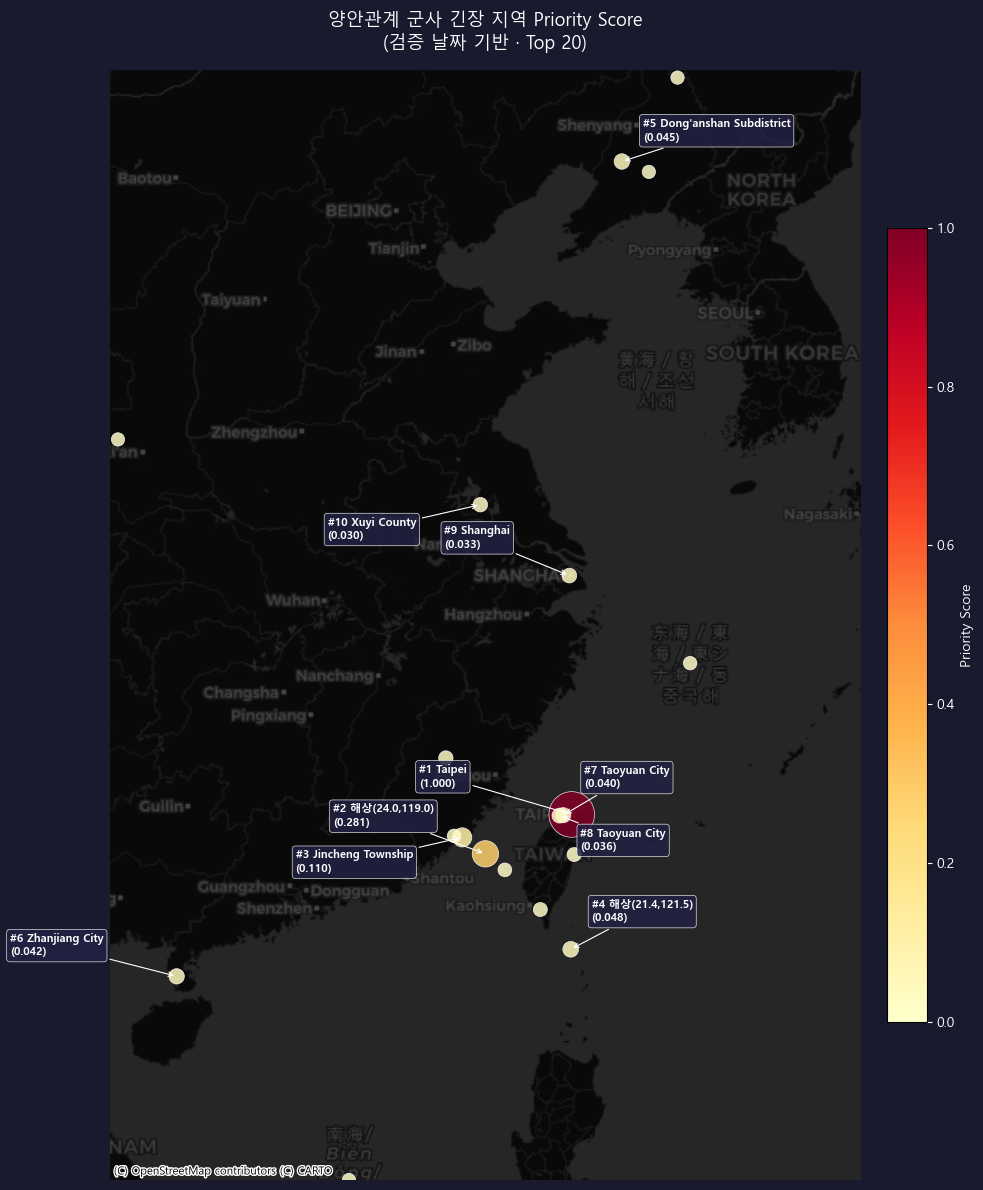

In [25]:
fig, ax = plt.subplots(figsize=(14, 12))

x_min, y_min = transformer.transform(108, 15)
x_max, y_max = transformer.transform(130, 43)

norm  = Normalize(vmin=0, vmax=1)
cmap  = plt.cm.YlOrRd
colors = [cmap(norm(s)) for s in gdf['priority_score']]
sizes  = 80 + gdf['priority_score'] * 1000

gdf.plot(
    ax=ax, color=colors, markersize=sizes,
    alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3
)

# ── 상위 10개 라벨 ───────────────────────────────────────────────
top10 = gdf.sort_values('priority_score', ascending=False).head(10).reset_index(drop=True)

offsets = [
    (-110,  20),  # #1 Taipei       → 왼쪽 위
    (-110,  20),  # #2 해상          → 왼쪽 위
    (-120, -25),  # #3 Jincheng     → 왼쪽 아래
    (  15,  20),  # #4 해상          → 오른쪽 위
    (  15,  15),  # #5 Dong'anshan  → 오른쪽 위
    (-120,  15),  # #6 Zhanjiang    → 왼쪽 위
    (  15,  20),  # #7 Taoyuan      → 오른쪽 위
    (  15, -25),  # #8 Taoyuan      → 오른쪽 아래
    ( -90,  20),  # #9 Shanghai     → 왼쪽 위
    (-110, -25),  # #10 Xuyi        → 왼쪽 아래
]

for i, row in top10.iterrows():
    label = row['city'] if row['city'] else \
            f"해상({row['ActionGeo_Lat']:.1f},{row['ActionGeo_Long']:.1f})"
    dx, dy = offsets[i]
    ax.annotate(
        f"#{i+1} {label}\n({row['priority_score']:.3f})",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(dx, dy), textcoords='offset points',
        color='white', fontsize=8, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='white', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#222244', alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.DarkMatter,
    zoom=5
)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Priority Score', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_axis_off()
fig.patch.set_facecolor('#1a1a2e')
ax.set_title(
    '양안관계 군사 긴장 지역 Priority Score\n(검증 날짜 기반 · Top 20)',
    color='white', fontsize=13, pad=15
)

plt.tight_layout()
plt.show()

In [26]:
# ── 관심 외 국가 제거 ────────────────────────────────────────────
remove_countries = ['Japan', 'Philippines', 'South Korea', 'North Korea']

coord_agg_final = coord_agg[
    ~coord_agg['country'].isin(remove_countries)
].copy()

print(f"제거 전 좌표 수: {len(coord_agg):,}")
print(f"제거 후 좌표 수: {len(coord_agg_final):,}")
print(f"\n[country 분포]")
print(coord_agg_final['country'].value_counts(dropna=False))

# ── 재정규화 및 Priority Score 재산출 ───────────────────────────
for raw, scaled in score_cols.items():
    coord_agg_final[scaled] = minmax.fit_transform(
        robust.fit_transform(coord_agg_final[[raw]])
    )

coord_agg_final['priority_score'] = sum(
    coord_agg_final[col] * w for col, w in weights.items()
)

# ── 최종 결과 출력 ───────────────────────────────────────────────
print("\n[최종 Priority Score 전체]")
display(coord_agg_final.sort_values('priority_score', ascending=False)[
    ['country', 'city', 'ActionGeo_Lat', 'ActionGeo_Long',
     'priority_score', 'total_events', 'val_events', 'importance_sum']
].reset_index(drop=True))

제거 전 좌표 수: 52
제거 후 좌표 수: 52

[country 분포]
country
China     33
Taiwan    15
None       4
Name: count, dtype: int64

[최종 Priority Score 전체]


,country,city,ActionGeo_Lat,ActionGeo_Long,priority_score,total_events,val_events,importance_sum
0,Taiwan,Taipei,25.05,121.53,1.000000,2786,491,474.75
1,None,None,24.00,119.00,0.280806,722,131,125.50
2,Taiwan,Jincheng Township,24.44,118.32,0.110434,340,51,50.25
3,None,None,21.42,121.50,0.048455,99,29,28.50
4,China,Dong'anshan Subdistrict,41.00,123.00,0.045383,104,28,26.00
5,China,Zhanjiang City,20.68,109.95,0.042145,58,28,28.00
6,Taiwan,Taoyuan City,25.03,121.28,0.039579,95,23,22.00
7,Taiwan,Taoyuan City,25.02,121.17,0.035784,68,22,22.00
8,China,Shanghai,31.22,121.46,0.032902,145,16,11.50
9,China,Xuyi County,32.98,118.85,0.029803,52,19,19.00


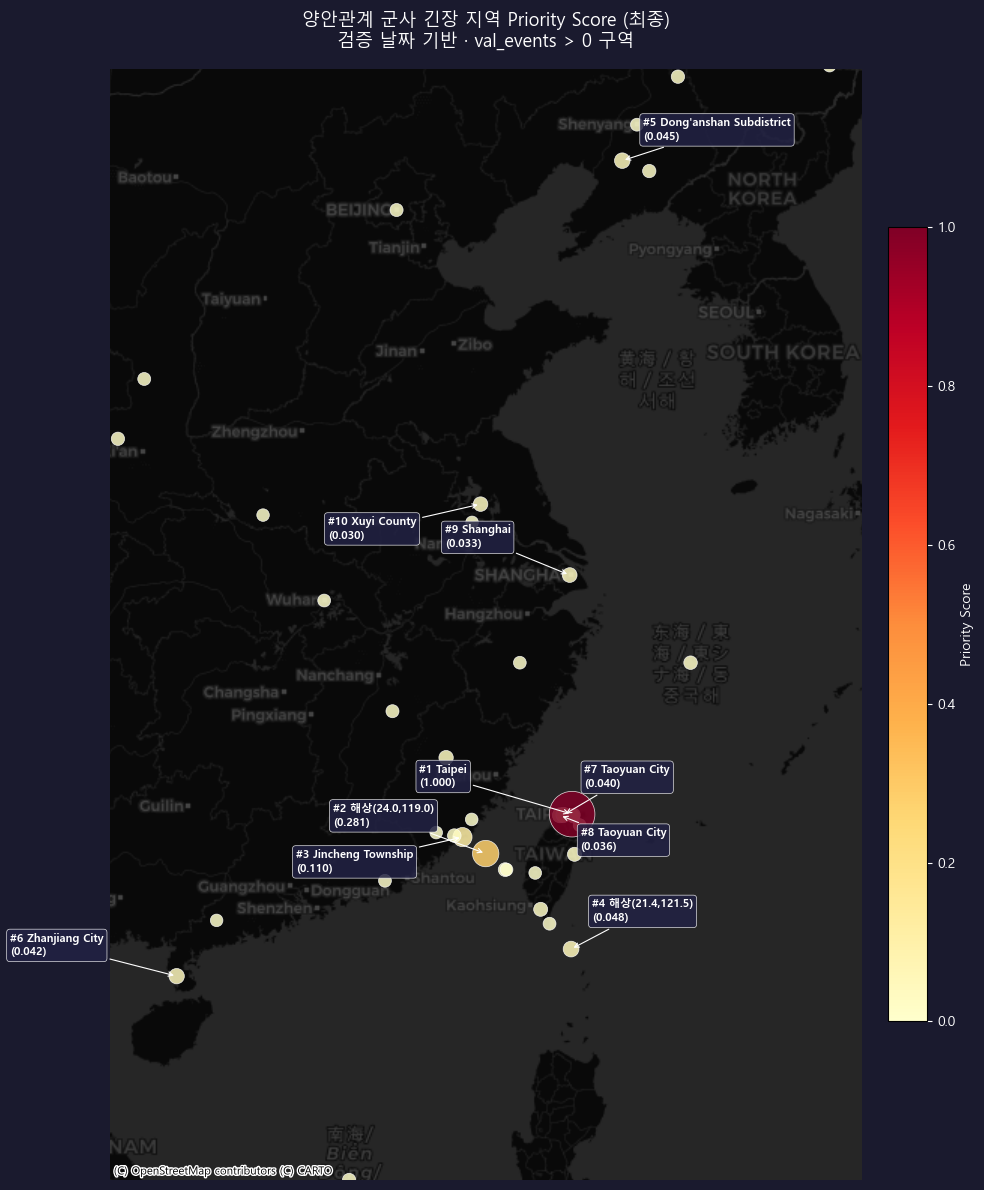

In [27]:
# ── val_events > 0 인 구역만 시각화 ────────────────────────────
coord_viz = coord_agg_final[coord_agg_final['val_events'] > 0].copy()

gdf_final = gpd.GeoDataFrame(
    coord_viz,
    geometry=[Point(xy) for xy in zip(
        coord_viz['ActionGeo_Long'],
        coord_viz['ActionGeo_Lat']
    )],
    crs='EPSG:4326'
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 12))

x_min, y_min = transformer.transform(108, 15)
x_max, y_max = transformer.transform(130, 43)

norm  = Normalize(vmin=0, vmax=1)
cmap  = plt.cm.YlOrRd
colors = [cmap(norm(s)) for s in gdf_final['priority_score']]
sizes  = 80 + gdf_final['priority_score'] * 1000

gdf_final.plot(
    ax=ax, color=colors, markersize=sizes,
    alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3
)

# ── 상위 10개 라벨 ───────────────────────────────────────────────
top10 = gdf_final.sort_values(
    'priority_score', ascending=False
).head(10).reset_index(drop=True)

offsets = [
    (-110,  20), (-110,  20), (-120, -25), (  15,  20),
    (  15,  15), (-120,  15), (  15,  20), (  15, -25),
    ( -90,  20), (-110, -25),
]

for i, row in top10.iterrows():
    label = row['city'] if row['city'] else \
            f"해상({row['ActionGeo_Lat']:.1f},{row['ActionGeo_Long']:.1f})"
    dx, dy = offsets[i]
    ax.annotate(
        f"#{i+1} {label}\n({row['priority_score']:.3f})",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(dx, dy), textcoords='offset points',
        color='white', fontsize=8, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='white', lw=0.8),
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#222244', alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.DarkMatter, zoom=5
)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Priority Score', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_axis_off()
fig.patch.set_facecolor('#1a1a2e')
ax.set_title(
    '양안관계 군사 긴장 지역 Priority Score (최종)\n'
    '검증 날짜 기반 · val_events > 0 구역',
    color='white', fontsize=13, pad=15
)

plt.tight_layout()
plt.show()